### Libraries

In [90]:
import pyreadstat
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import chi2
from scipy.stats import chi2_contingency
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap.umap_ as umap
from mpl_toolkits.mplot3d import Axes3D
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier

## Load data

In [91]:
# df_ch = pyreadstat.read_sav(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.sav")[0]      #Local dataset
df_ch = pd.read_spss(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.sav")      #Local dataset
df_ch.head(2)

,HH1,HH2,LN,UF1,UF2,UF3,UFINT,UF4,UF5,UF6,...,wscoreu,windex5u,windex10u,wscorer,windex5r,windex10r,ListCat,PSU,dstratum,stratum
0,1.0,3.0,5.0,1.0,3.0,5.0,103.0,4.0,103.0,100.0,...,NaN,NaN,NaN,-0.831559,Second,3rd decile,With child U5 during listing,1.0,"U5 HH, Province 1 Rural",Province 1 Rural
1,1.0,5.0,5.0,1.0,5.0,5.0,104.0,2.0,104.0,100.0,...,NaN,NaN,NaN,-1.220021,Poorest,2nd decile,With child U5 during listing,1.0,"U5 HH, Province 1 Rural",Province 1 Rural


## Rename variables and remove the coded entries

In [92]:
# Renaming the columns
feature_coded = df_ch[['AN4', 'AN8', 'CA1', 'CA14', 'HH6', 'HL4', 'melevel1', 'cinsurance', 'HH7c', 'windex5', 'WAZ2', 'HAZ2', 'WHZ2']]
df1 = feature_coded.rename(columns={
    'AN4': 'child_age',
    'AN8': 'child_weight',
    # 'BD2': 'ever_breastfed',
    'CA1': 'diarrhoea_last_2_weeks',
    'CA14': 'fever_last_2_weeks',
    'HH6': 'area',
    'HL4': 'child_sex',
    'melevel1': 'mother_education',
    'cinsurance': 'health_insurance',
    'HH7c': 'province',
    'windex5': 'wealth_index',
    'WAZ2': 'underweight',
    'HAZ2': 'stunting',
    'WHZ2': 'wasting'
})

# Remove rows with coded entries in each column
coded_child_weight = ['OTHER', 'CHILD REFUSED', 'CHILD NOT PRESENT', 'RESPONDENT REFUSED']
coded_underweight = ['Z-score out of range', 'Not measured', 'Measurement out of range']
coded_stunting = ['Not measured', 'Measurement out of range']
coded_wasting = ['Measurement out of range', ' Measurement out of range', 'Not measured']
coded_diarrhoea = ['DK', 'NO RESPONSE']
coded_fever = ['DK']
coded_insurance = ['Missing/DK']
coded_wealth_index = [0.0]
coded_mother_education = ['Missing/DK']

df1 = df1[~df1['child_weight'].isin(coded_child_weight)]
df1 = df1[~df1['underweight'].isin(coded_underweight)]
df1 = df1[~df1['stunting'].isin(coded_stunting)]
df1 = df1[~df1['wasting'].isin(coded_wasting)] 
df1 = df1[~df1['diarrhoea_last_2_weeks'].isin(coded_diarrhoea)]
df1 = df1[~df1['fever_last_2_weeks'].isin(coded_fever)]
df1 = df1[~df1['health_insurance'].isin(coded_insurance)]
df1 = df1[~df1['wealth_index'].isin(coded_wealth_index)]
df1 = df1[~df1['mother_education'].isin(coded_mother_education)]

# Drop missing values and make a copy to avoid chained assignment issues
df1.dropna()
df1.head(2)

,child_age,child_weight,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,province,wealth_index,underweight,stunting,wasting
0,1.0,7.8,NO,NO,RURAL,MALE,Secondary (Gr 9-12),Without insurance,Province 1,Poorest,-2.94,-3.53,-1.69
1,3.0,12.5,NO,YES,RURAL,MALE,Secondary (Gr 9-12),Without insurance,Province 1,Poorest,-1.93,-2.58,-0.65


Ever breastfed has 2940 missing entries and this variable has very weak significance supported by cramer's v test and feature importance check.

In [93]:
df2 = df1.copy()
df2['underweight'] = pd.to_numeric(df2['underweight'], errors='coerce')
df2['stunting'] = pd.to_numeric(df2['stunting'], errors='coerce')
df2['wasting'] = pd.to_numeric(df2['wasting'], errors='coerce')

# Convert to Binary Response Variables
df2['underweight'] = [0 if -2 <= x < 2 else 1 for x in df2['underweight']]
df2['stunting'] = [0 if -2 <= x < 2 else 1 for x in df2['stunting']]
df2['wasting'] = [0 if -2 <= x < 2 else 1 for x in df2['wasting']]

In [94]:
# print(df2['child_weight'].value_counts().to_string())

## Create 'status' as response variable

In [95]:
df2['status'] = df2[['underweight', 'stunting', 'wasting']].apply(lambda x: 1 if any(i == 1 for i in x) else 0, axis=1)
df3 = df2.drop(['underweight', 'stunting', 'wasting'], axis=1)
df3.head(2)

,child_age,child_weight,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,province,wealth_index,status
0,1.0,7.8,NO,NO,RURAL,MALE,Secondary (Gr 9-12),Without insurance,Province 1,Poorest,1
1,3.0,12.5,NO,YES,RURAL,MALE,Secondary (Gr 9-12),Without insurance,Province 1,Poorest,1


In [96]:
# Copy your original DataFrame
df_encoded = df3.copy()

# Label Encoding for binary categories
binary_cols = [
    'diarrhoea_last_2_weeks',
    'fever_last_2_weeks',
    'area',
    'child_sex',
    'health_insurance'
]
le = LabelEncoder()
for col in binary_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Ordinal encoding for ordinal category (mother education)
edu_order = {
    'None': 0,
    'Basic (Gr 1-8)': 1,
    'Secondary (Gr 9-12)': 2,
    'Higher': 3
}
df_encoded['mother_education'] = df3['mother_education'].map(edu_order)

# Ordinal encoding for ordinal category (wealth index)
wealth_order = {
    'Poorest': 1,
    'Second': 2,
    'Middle': 3,
    'Fourth': 4,
    'Richest': 5
}
df_encoded['wealth_index'] = df3['wealth_index'].map(wealth_order)

# Convert child_weight to float if it's actually numeric
df_encoded['child_weight'] = pd.to_numeric(df1['child_weight'], errors='raise')

df_encoded.head()


,child_age,child_weight,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,province,wealth_index,status
0,1.0,7.8,0,0,0,1,2.0,1,Province 1,1.0,1
1,3.0,12.5,0,1,0,1,2.0,1,Province 1,1.0,1
2,2.0,11.1,1,0,0,0,1.0,1,Province 1,1.0,0
3,1.0,9.3,1,1,0,0,1.0,1,Province 1,1.0,0
4,4.0,14.7,0,0,0,0,1.0,1,Province 1,1.0,0


In [97]:
vc = df1['health_insurance'].value_counts()
vc_pct = df1['health_insurance'].value_counts(normalize=True) * 100

summary = vc.astype(str) + " (" + vc_pct.round(2).astype(str) + ")"
print(summary)

health_insurance
Without insurance    6262 (95.57)
With insurance         290 (4.43)
Missing/DK                0 (0.0)
dtype: object


### One-hot encode to nominal feature

In [98]:
# One-hot encoding for province (nominal)
df_one_hot_encoded = pd.get_dummies(df_encoded, columns=['province'], drop_first=True)
df_one_hot_encoded = df_one_hot_encoded.astype({col: int for col in df_one_hot_encoded.columns if df_one_hot_encoded[col].dtype == 'bool'})

## Standardize continuous feature

In [99]:
# Standardize childe weight
df = df_one_hot_encoded.copy()
scaler = StandardScaler()
df['child_weight'] = scaler.fit_transform(df[['child_weight']])
df.head(2)

,child_age,child_weight,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,wealth_index,status,province_Gandaki Province,province_Karnali Province,province_Province 1,province_Province 2,province_Province 5,province_Sudoorpaschim Province
0,1.0,-1.066081,0,0,0,1,2.0,1,1.0,1,0,0,1,0,0,0
1,3.0,0.434428,0,1,0,1,2.0,1,1.0,1,0,0,1,0,0,0


## Childern counts vs malnutrition status

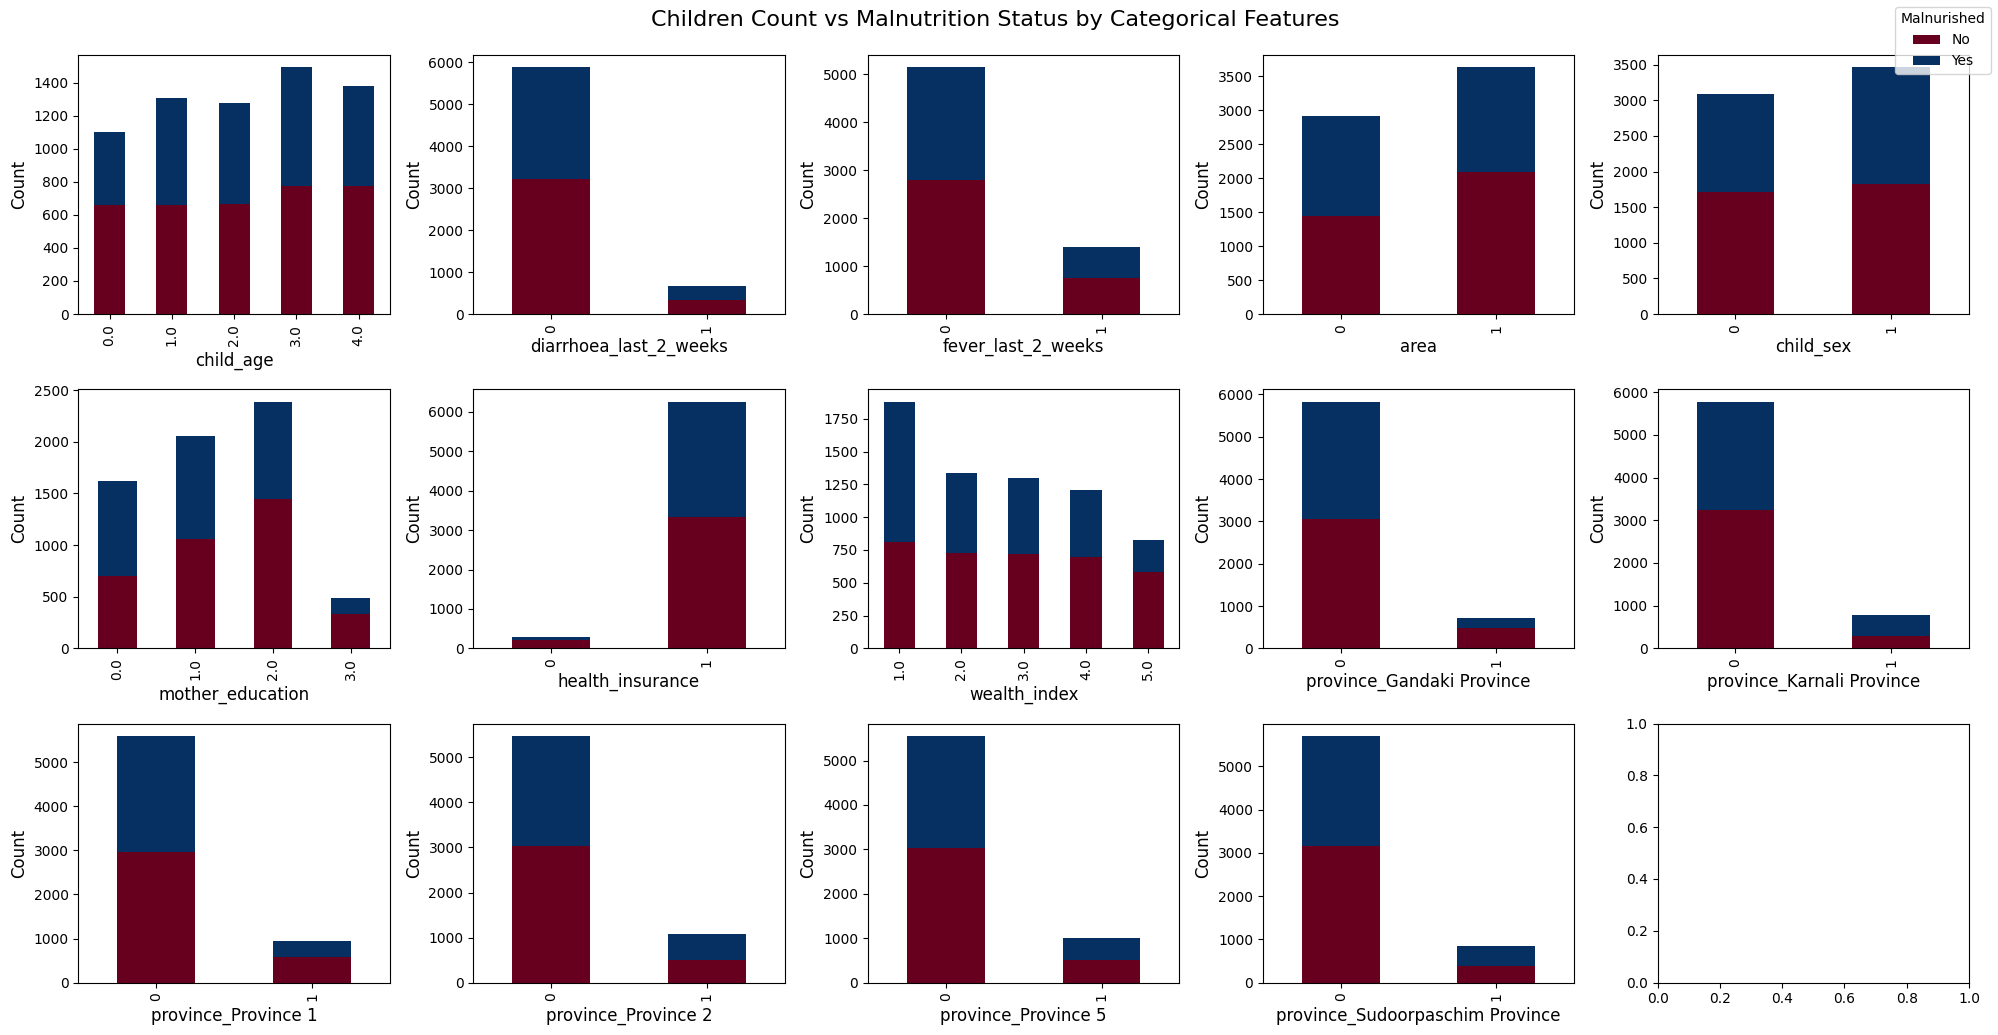

In [100]:
# List of features to plot
features = [
    'child_age', 'diarrhoea_last_2_weeks', 'fever_last_2_weeks', 'area', 'child_sex', 'mother_education', 'health_insurance', 'wealth_index',     
    'province_Gandaki Province', 'province_Karnali Province', 'province_Province 1',	'province_Province 2',	'province_Province 5',	'province_Sudoorpaschim Province'
]

# Set up a grid for 2 rows × 4 columns
fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(20, 10))

# Flatten axes for easy iteration
axes = axes.flatten()

for i, feature in enumerate(features):
    ctab = pd.crosstab(df[feature], df['status'])
    ctab.plot(kind='bar', stacked=True, colormap='RdBu', ax=axes[i], legend=False)
    axes[i].set_ylabel("Count", fontsize=12)
    axes[i].set_xlabel(feature, fontsize=12)

# Add one global legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, ['No', 'Yes'], title='Malnurished', loc='upper right')

plt.tight_layout()
plt.suptitle("Children Count vs Malnutrition Status by Categorical Features", fontsize=16, y=1.03)
plt.show()

### Violinplot of continuous feature

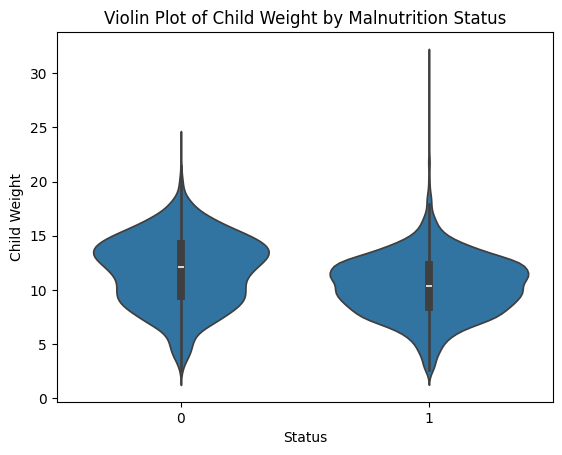

In [101]:
sns.violinplot(x='status', y='child_weight', data=df_one_hot_encoded)
plt.title("Violin Plot of Child Weight by Malnutrition Status")
plt.xlabel("Status")
plt.ylabel("Child Weight")
plt.show()

## Feature Importance Check for Categorical Features

### Contingency table for categorical features

In [102]:
vc = df['child_age'].value_counts()
vc_pct = df['child_age'].value_counts(normalize=True) * 100

summary = vc.astype(str) + " (" + vc_pct.round(2).astype(str) + ")"
print(summary)

child_age
3.0    1492 (22.77)
4.0    1380 (21.06)
1.0     1304 (19.9)
2.0    1276 (19.47)
0.0    1100 (16.79)
dtype: object


In [103]:
# # Listing all categorical features
# cat_columns = [
#     'child_age', 'diarrhoea_last_2_weeks', 'fever_last_2_weeks', 'area', 'child_sex', 'mother_education', 'health_insurance', 'wealth_index',     
#     'province'
# ]

# # Contingency table for categorical features
# for col in cat_columns:
#     table = pd.crosstab(df_encoded[col], df_encoded['status'], margins=False)

#     # Calculate row-wise percentages
#     row_pct = table.div(table.sum(axis=1), axis=0) * 100
#     row_pct = row_pct.round(1)  # Round to 1 decimal

#     # Combine count and percentage for pretty output
#     combined = table.astype(str) + " (" + row_pct.astype(str) + ")"

#     print(f"\nContingency table for {col}:\n{combined}\n")

In [104]:
# Listing all categorical features
cat_columns = [
    'child_age', 'diarrhoea_last_2_weeks', 'fever_last_2_weeks', 'area', 'child_sex', 'mother_education', 'health_insurance', 'wealth_index',     
    'province_Gandaki Province', 'province_Karnali Province', 'province_Province 1',	'province_Province 2',	'province_Province 5',	'province_Sudoorpaschim Province'
]

# Contingency table for categorical features
for col in cat_columns:
    table = pd.crosstab(df[col], df['status'], margins=False)

    # Calculate row-wise percentages
    row_pct = table.div(table.sum(axis=1), axis=0) * 100
    row_pct = row_pct.round(1)  # Round to 1 decimal

    # Combine count and percentage for pretty output
    combined = table.astype(str) + " (" + row_pct.astype(str) + ")"

    print(f"\nContingency table for {col}:\n{combined}\n")



Contingency table for child_age:
status              0           1
child_age                        
0.0        657 (59.7)  443 (40.3)
1.0        662 (50.8)  642 (49.2)
2.0        666 (52.2)  610 (47.8)
3.0        777 (52.1)  715 (47.9)
4.0        773 (56.0)  607 (44.0)


Contingency table for diarrhoea_last_2_weeks:
status                            0            1
diarrhoea_last_2_weeks                          
0                       3210 (54.6)  2667 (45.4)
1                        325 (48.1)   350 (51.9)


Contingency table for fever_last_2_weeks:
status                        0            1
fever_last_2_weeks                          
0                   2788 (54.2)  2360 (45.8)
1                    747 (53.2)   657 (46.8)


Contingency table for area:
status            0            1
area                            
0       1445 (49.5)  1476 (50.5)
1       2090 (57.6)  1541 (42.4)


Contingency table for child_sex:
status               0            1
child_sex                  

In [105]:
X_cat = df[cat_columns].copy()
y = df['status']

# # Label encode all categorical variables if needed
# for col in X_cat.columns:
#     if X_cat[col].dtype == 'object':
#         X_cat[col] = LabelEncoder().fit_transform(X_cat[col])

chi_vals, p_vals = chi2(X_cat, y)

chi_df = pd.DataFrame({'Feature': X_cat.columns, 'Chi2': chi_vals, 'p-value': p_vals})
print(chi_df.sort_values(by='Chi2', ascending=False))


                            Feature        Chi2       p-value
7                      wealth_index  121.289475  3.302509e-28
5                  mother_education  107.392252  3.652316e-25
9         province_Karnali Province   69.661074  7.042223e-17
8         province_Gandaki Province   38.085818  6.770041e-10
13  province_Sudoorpaschim Province   23.278844  1.401330e-06
11              province_Province 2   23.068611  1.563220e-06
3                              area   19.014275  1.297442e-05
10              province_Province 1   15.701375  7.417024e-05
1            diarrhoea_last_2_weeks    9.155200  2.480123e-03
12              province_Province 5    5.488034  1.914706e-02
4                         child_sex    2.235867  1.348410e-01
6                  health_insurance    1.163027  2.808386e-01
0                         child_age    0.929861  3.348991e-01
2                fever_last_2_weeks    0.316078  5.739741e-01


### Cramer's V Test
$
V = \sqrt{ \frac{\chi^2 / n}{\min(k - 1, r - 1)} }
$

In [80]:
cramers_v_results = {}

for col in cat_columns:
    if col != 'status':
        table = pd.crosstab(df[col], df['status'])
        chi2, _, _, _ = chi2_contingency(table)
        n = table.sum().sum()
        phi2 = chi2 / n
        r, k = table.shape
        dof = min(k - 1, r - 1)
        V = np.sqrt(phi2 / dof)

        cramers_v_results[col] = V
        # print(f"{col}: Cramér's V = {V:.4f}")

cramers_v_sorted = pd.Series(cramers_v_results).sort_values(ascending=False)
print(cramers_v_sorted)

wealth_index                       0.168761
mother_education                   0.157582
province_Karnali Province          0.109288
area                               0.080374
province_Gandaki Province          0.080322
province_Province 2                0.064480
province_Sudoorpaschim Province    0.063399
child_age                          0.063178
health_insurance                   0.062584
province_Province 1                0.052512
diarrhoea_last_2_weeks             0.038965
province_Province 5                0.030999
child_sex                          0.026593
fever_last_2_weeks                 0.007463
dtype: float64


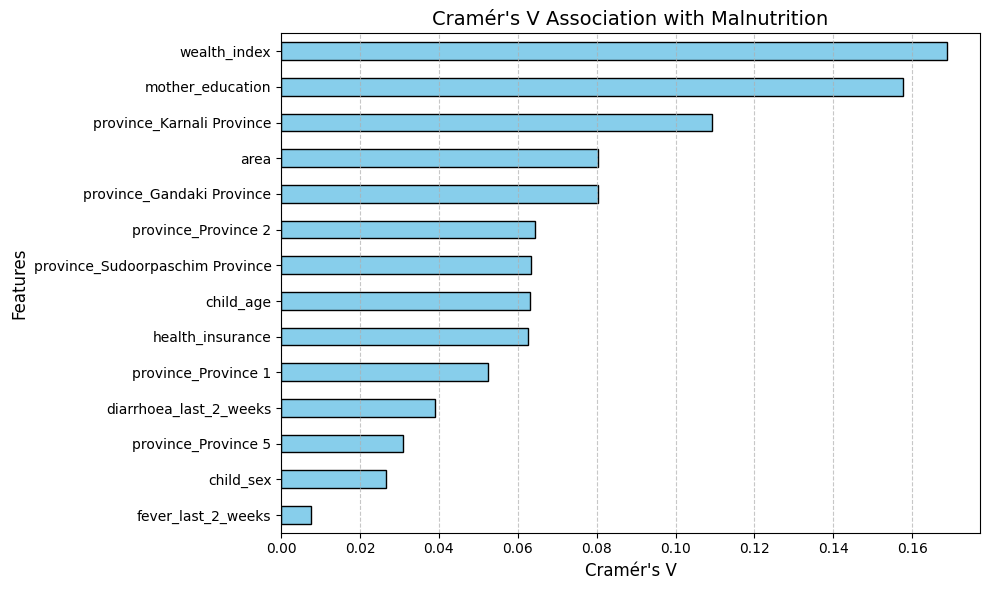

In [45]:
# Plotting the sorted Cramér's V values
plt.figure(figsize=(10, 6))
cramers_v_sorted.plot(kind='barh', color='skyblue', edgecolor='black')

plt.title("Cramér's V Association with Malnutrition", fontsize=14)
plt.xlabel("Cramér's V", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.gca().invert_yaxis()  # Highest at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Data visualization

c:\Users\dbastola2022\AppData\Local\Programs\Python\Python310\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


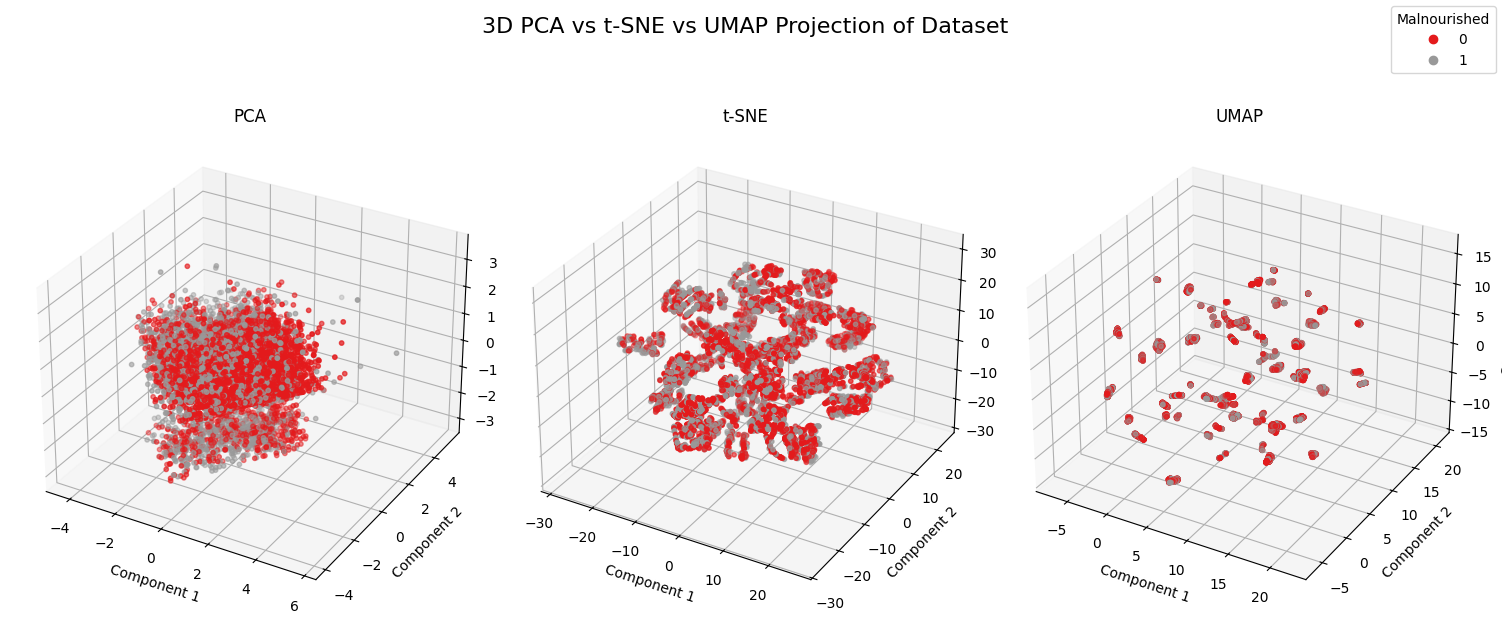

In [46]:
# Encode and scale the dataset
X = pd.get_dummies(df.drop(columns='status'), drop_first=True)
y = df['status']
X_scaled = StandardScaler().fit_transform(X)

# Reduce with PCA (3D)
X_pca = PCA(n_components=3).fit_transform(X_scaled)

# Reduce with t-SNE (3D)
X_tsne = TSNE(n_components=3, random_state=42).fit_transform(X_scaled)

# Reduce with UMAP (3D)
X_umap = umap.UMAP(n_components=3, random_state=42).fit_transform(X_scaled)

# Plot
fig = plt.figure(figsize=(15, 7))

# PCA
ax1 = fig.add_subplot(131, projection='3d')
scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=y, cmap='Set1', s=10)
ax1.set_title("PCA")
ax1.set_xlabel("Component 1")
ax1.set_ylabel("Component 2")
ax1.set_zlabel("Component 3")

# t-SNE
ax2 = fig.add_subplot(132, projection='3d')
scatter2 = ax2.scatter(X_tsne[:, 0], X_tsne[:, 1], X_tsne[:, 2], c=y, cmap='Set1', s=10)
ax2.set_title("t-SNE")
ax2.set_xlabel("Component 1")
ax2.set_ylabel("Component 2")
ax2.set_zlabel("Component 3")

# UMAP
ax3 = fig.add_subplot(133, projection='3d')
scatter3 = ax3.scatter(X_umap[:, 0], X_umap[:, 1], X_umap[:, 2], c=y, cmap='Set1', s=10)
ax3.set_title("UMAP")
ax3.set_xlabel("Component 1")
ax3.set_ylabel("Component 2")
ax3.set_zlabel("Component 3")

# Legend (common)
fig.legend(*scatter1.legend_elements(), title="Malnourished", loc="upper right")
fig.suptitle("3D PCA vs t-SNE vs UMAP Projection of Dataset", fontsize=16)
plt.tight_layout()
plt.show()

## Save final data

In [ ]:
# df.to_csv(r'C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.csv', index=False)

---

## Boruta Algorithm for feature selection

In [48]:
# Separate features and target
X = df.drop(columns='status')
y = df['status']

# Convert to numpy arrays (Boruta requires numpy arrays)
X_np = X.values
y_np = y.values

# Define the RandomForest model for Boruta
rf = RandomForestClassifier(n_jobs=-1, class_weight='balanced', max_depth=5, random_state=42)

# Initialize Boruta
boruta_selector = BorutaPy(
    estimator=rf,
    n_estimators='auto',
    verbose=2,
    random_state=42
)

# Fit Boruta
boruta_selector.fit(X_np, y_np)

Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	5
Tentative: 	0
Rejected: 	10


BorutaPy finished running.

Iteration: 	9 / 100
Confirmed: 	5
Tentative: 	0
Rejected: 	10


BorutaPy(estimator=RandomForestClassifier(class_weight='balanced', max_depth=5,
                                          n_estimators=109, n_jobs=-1,
                                          random_state=RandomState(MT19937) at 0x25C83236F40),
         n_estimators='auto',
         random_state=RandomState(MT19937) at 0x25C83236F40, verbose=2)

In [49]:

# Get selected feature names
selected_features = X.columns[boruta_selector.support_].tolist()
print("Selected Features by Boruta:")
print(selected_features)

Selected Features by Boruta:
['child_age', 'child_weight', 'mother_education', 'wealth_index', 'province_Karnali Province']
